In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
from pathlib import Path
import re
from typing import NamedTuple, Literal, Optional

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import torch
from tqdm.auto import tqdm, trange

from src.data import get_electrode_df, add_metadata_features

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "5"  # Limit OpenMP
os.environ["MKL_NUM_THREADS"] = "5"  # Limit MKL (Intel Math Kernel Library)
os.environ["OPENBLAS_NUM_THREADS"] = "5"  # Limit OpenBLAS
os.environ["NUMEXPR_MAX_THREADS"] = "5"  # Limit NumExpr if installed

In [34]:
all_epochs = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))
all_electrode_dfs = list(Path("outputs/causal4/find_speech_responsive").glob("*_results.csv"))
As_path = "outputs/causal4/unify_As/results.csv"
A_decoders_path = "outputs/causal4/unify_As/unified_decoders.pt"
outdir = "."

include_rois = ["superiortemporal", "postcentral", "precentral", "supramarginal", "inferiortemporal", "middletemporal",
                "parsopercularis", "caudalmiddlefrontol", "lateralorbitofrontal", "temporalpole", "inferiorparietal",
                "rostralmiddlefrontal", "parstriangularis"]

In [10]:
epochs = {re.findall(r"(EC[\d]+)_epo", str(path))[0]: mne.read_epochs(path)
          for path in all_epochs}
for ep in epochs.values():
    ep.metadata = add_metadata_features(ep.metadata)

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC278_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
1152 matching events found
No baseline correction applied
0 projection items activated
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC270_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
432 matching events found
No baseline correction applied
0 projection items activated
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC253_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 73 columns
864 matching events found
No baseline correc

In [13]:
As_df = pd.read_csv(As_path)
As_df.head()

,subject,population_name,phoneme_pair,smin,smax,num_electrodes,roc_auc,f1_macro,accuracy
0,EC250,superiortemporal,bm,40,70,12,0.992,0.929259,0.93
1,EC282,superiortemporal,dn,40,70,4,0.992,0.959596,0.96
2,EC253,superiortemporal,dn,40,70,19,0.988,0.919798,0.92
3,EC250,superiortemporal,dn,40,70,10,0.956,0.939798,0.94
4,EC253,superiortemporal,bm,40,70,9,0.956,0.919850,0.92


In [14]:
A_data = torch.load(A_decoders_path)

/tmp/ipykernel_2119601/1180239946.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  A_data = torch.load(A_decoders_path)


## Estimate neurometric curves

In [35]:
all_outcomes = []
for population_key, outcomes in A_data["held_out_outcomes"].items():
    subject, population_name, phoneme_pair = population_key
    if population_name not in include_rois:
        continue
    outcomes = outcomes.groupby("epoch_idx").decoder_proba.mean().to_frame() \
        .merge(epochs[subject].metadata, left_index=True, right_index=True)
    outcomes["subject"] = subject
    outcomes["A_population_name"] = population_name

    all_outcomes.append(outcomes.rename_axis("epoch_idx").reset_index())

In [40]:
all_outcomes_df = pd.concat(all_outcomes, ignore_index=True)
all_outcomes_df["site"] = all_outcomes_df["subject"] + " " + all_outcomes_df["A_population_name"]

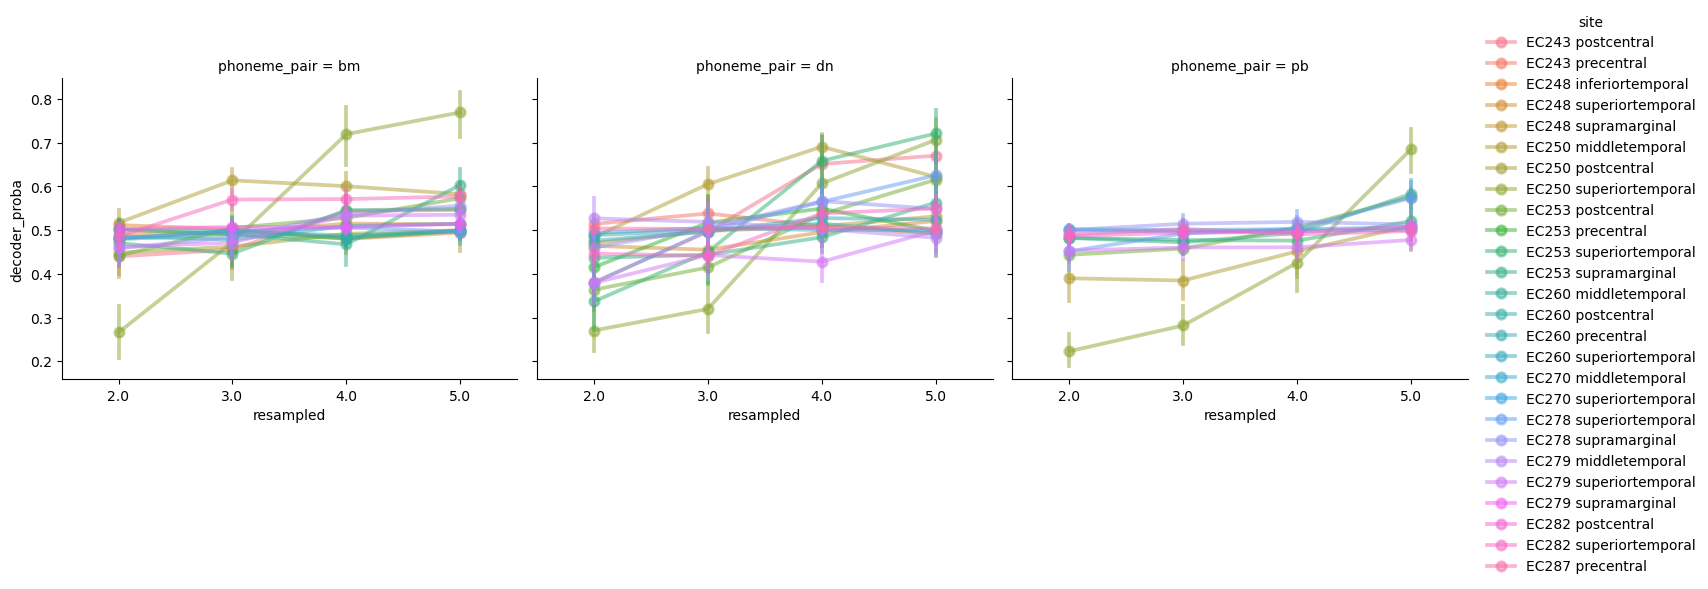

In [41]:
sns.catplot(data=all_outcomes_df, x="resampled", y="decoder_proba", kind="point", hue="site",
            col="phoneme_pair",
            alpha=0.5)